Time step 0/500
Time step 50/500
Time step 100/500
Time step 150/500
Time step 200/500
Time step 250/500
Time step 300/500
Time step 350/500
Time step 400/500
Time step 450/500
Simulation completed.


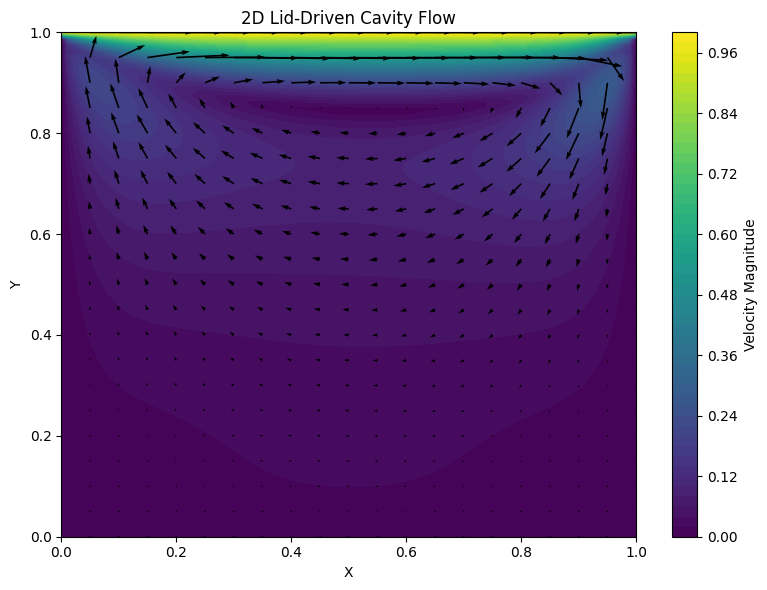

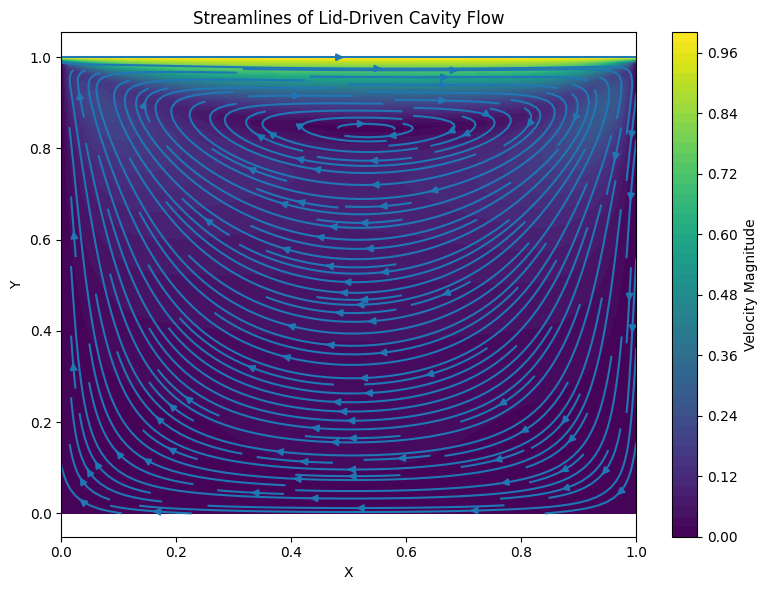

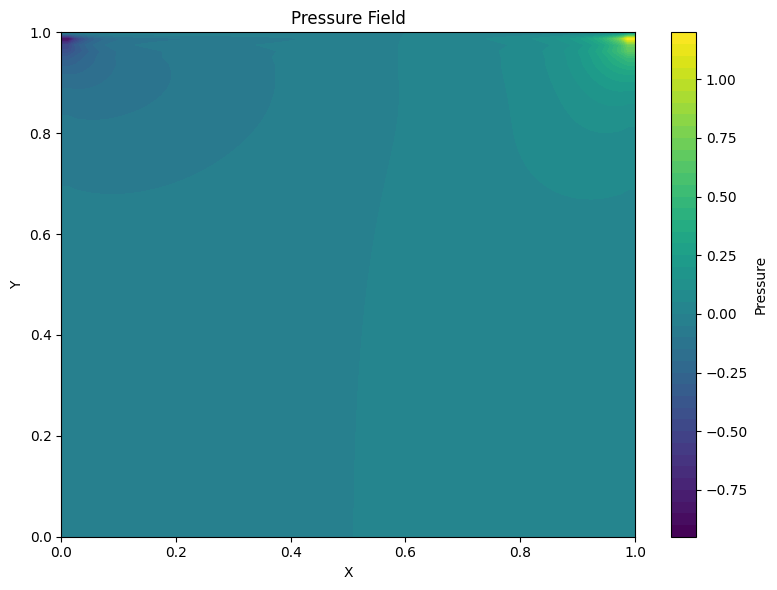

AttributeError: 'QuadContourSet' object has no attribute 'collections'

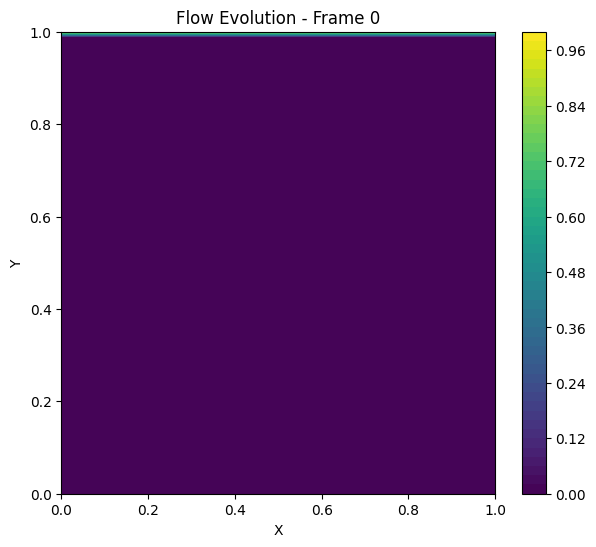

In [6]:
# ============================================================
# 2D Lid-Driven Cavity Flow Solver (Navier-Stokes Equations)
# ============================================================
#
# Description:
# This notebook solves the classic 2D lid-driven cavity flow
# problem using the incompressible Navier-Stokes equations
# with a finite difference method.
#
# Features:
# - Velocity field computation
# - Pressure Poisson equation
# - Streamlines visualization
# - Velocity magnitude contour
# - Animated flow evolution
#
# Author: ChatGPT
# Language: Python
#
# ============================================================

# ============================================================
# Imports
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ============================================================
# Simulation Parameters
# ============================================================

nx = 81              # Grid points in x
ny = 81              # Grid points in y

Lx = 1.0             # Domain length in x
Ly = 1.0             # Domain length in y

dx = Lx / (nx - 1)
dy = Ly / (ny - 1)

rho = 1.0            # Density
nu = 0.01            # Kinematic viscosity

dt = 0.001           # Time step
nt = 500             # Number of time steps
nit = 50             # Pressure Poisson iterations

# Lid velocity
u_lid = 1.0

# ============================================================
# Grid
# ============================================================

x = np.linspace(0, Lx, nx)
y = np.linspace(0, Ly, ny)

X, Y = np.meshgrid(x, y)

# ============================================================
# Initialize Fields
# ============================================================

u_field = np.zeros((ny, nx))
v_field = np.zeros((ny, nx))
p_field = np.zeros((ny, nx))

b = np.zeros((ny, nx))

# ============================================================
# Build RHS for Pressure Poisson Equation
# ============================================================

def build_up_b(b, rho, dt, u, v, dx, dy):

    b[1:-1, 1:-1] = (
        rho * (
            (1/dt) * (
                (u[1:-1, 2:] - u[1:-1, 0:-2]) / (2*dx) +
                (v[2:, 1:-1] - v[0:-2, 1:-1]) / (2*dy)
            )
            -
            ((u[1:-1, 2:] - u[1:-1, 0:-2]) / (2*dx))**2
            -
            2 * (
                ((u[2:, 1:-1] - u[0:-2, 1:-1]) / (2*dy)) *
                ((v[1:-1, 2:] - v[1:-1, 0:-2]) / (2*dx))
            )
            -
            ((v[2:, 1:-1] - v[0:-2, 1:-1]) / (2*dy))**2
        )
    )

    return b

# ============================================================
# Pressure Poisson Solver
# ============================================================

def pressure_poisson(p, dx, dy, b):

    pn = np.empty_like(p)

    for q in range(nit):

        pn = p.copy()

        p[1:-1, 1:-1] = (
            (
                (pn[1:-1, 2:] + pn[1:-1, 0:-2]) * dy**2 +
                (pn[2:, 1:-1] + pn[0:-2, 1:-1]) * dx**2
            ) /
            (2 * (dx**2 + dy**2))
            -
            dx**2 * dy**2 /
            (2 * (dx**2 + dy**2)) *
            b[1:-1, 1:-1]
        )

        # Boundary conditions
        p[:, -1] = p[:, -2]     # dp/dx = 0 at x = 1
        p[:, 0] = p[:, 1]       # dp/dx = 0 at x = 0
        p[0, :] = p[1, :]       # dp/dy = 0 at y = 0
        p[-1, :] = 0            # p = 0 at y = 1

    return p

# ============================================================
# Time Integration
# ============================================================

frames = []

for n in range(nt):

    un = u_field.copy()
    vn = v_field.copy()

    b = build_up_b(b, rho, dt, un, vn, dx, dy)

    p_field = pressure_poisson(p_field, dx, dy, b)

    # Momentum equations
    u_field[1:-1, 1:-1] = (
        un[1:-1, 1:-1]
        -
        un[1:-1, 1:-1] * dt/dx *
        (un[1:-1, 1:-1] - un[1:-1, 0:-2])
        -
        vn[1:-1, 1:-1] * dt/dy *
        (un[1:-1, 1:-1] - un[0:-2, 1:-1])
        -
        dt/(2*rho*dx) *
        (p_field[1:-1, 2:] - p_field[1:-1, 0:-2])
        +
        nu * (
            dt/dx**2 *
            (un[1:-1, 2:] - 2*un[1:-1, 1:-1] + un[1:-1, 0:-2])
            +
            dt/dy**2 *
            (un[2:, 1:-1] - 2*un[1:-1, 1:-1] + un[0:-2, 1:-1])
        )
    )

    v_field[1:-1, 1:-1] = (
        vn[1:-1, 1:-1]
        -
        un[1:-1, 1:-1] * dt/dx *
        (vn[1:-1, 1:-1] - vn[1:-1, 0:-2])
        -
        vn[1:-1, 1:-1] * dt/dy *
        (vn[1:-1, 1:-1] - vn[0:-2, 1:-1])
        -
        dt/(2*rho*dy) *
        (p_field[2:, 1:-1] - p_field[0:-2, 1:-1])
        +
        nu * (
            dt/dx**2 *
            (vn[1:-1, 2:] - 2*vn[1:-1, 1:-1] + vn[1:-1, 0:-2])
            +
            dt/dy**2 *
            (vn[2:, 1:-1] - 2*vn[1:-1, 1:-1] + vn[0:-2, 1:-1])
        )
    )

    # ========================================================
    # Boundary Conditions
    # ========================================================

    # Velocity BCs

    u_field[0, :] = 0
    u_field[:, 0] = 0
    u_field[:, -1] = 0

    # Moving lid
    u_field[-1, :] = u_lid

    v_field[0, :] = 0
    v_field[-1, :] = 0
    v_field[:, 0] = 0
    v_field[:, -1] = 0

    # Store frames every 10 iterations
    if n % 10 == 0:
        frames.append(np.sqrt(u_field**2 + v_field**2))

    # Progress
    if n % 50 == 0:
        print(f"Time step {n}/{nt}")

print("Simulation completed.")

# ============================================================
# Velocity Magnitude
# ============================================================

velocity_magnitude = np.sqrt(u_field**2 + v_field**2)

# ============================================================
# Plot Velocity Magnitude
# ============================================================

plt.figure(figsize=(8, 6))

contour = plt.contourf(
    X, Y,
    velocity_magnitude,
    50,
)

plt.colorbar(label='Velocity Magnitude')

plt.quiver(
    X[::4, ::4],
    Y[::4, ::4],
    u_field[::4, ::4],
    v_field[::4, ::4]
)

plt.xlabel('X')
plt.ylabel('Y')

plt.title('2D Lid-Driven Cavity Flow')

plt.tight_layout()
plt.savefig('velocity2dCavity.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# Streamlines Plot
# ============================================================

plt.figure(figsize=(8, 6))

plt.contourf(
    X, Y,
    velocity_magnitude,
    50,
)

plt.colorbar(label='Velocity Magnitude')

plt.streamplot(
    X,
    Y,
    u_field,
    v_field,
    density=2
)

plt.xlabel('X')
plt.ylabel('Y')

plt.title('Streamlines of Lid-Driven Cavity Flow')

plt.tight_layout()
plt.savefig('streamlines2dCavity.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# Pressure Field
# ============================================================

plt.figure(figsize=(8, 6))

plt.contourf(
    X, Y,
    p_field,
    50,
)

plt.colorbar(label='Pressure')

plt.xlabel('X')
plt.ylabel('Y')

plt.title('Pressure Field')

plt.tight_layout()
plt.savefig('pressure2dCavity.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# Animation or Final Frame Export
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

def animate(i):

    ax.clear()

    contour = ax.contourf(
        X,
        Y,
        frames[i],
        50
    )

    ax.set_title(f'Flow Evolution - Frame {i}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

# ============================================================
# Create Animation
# ============================================================

ani = FuncAnimation(
    fig,
    animate,
    frames=len(frames),
    interval=100,
    blit=False
)

# ============================================================
# OPTION 1:
# Save Animation as GIF
# ============================================================

# Uncomment this section if desired

# ani.save(
#     'lid_driven_cavity.gif',
#     writer='pillow',
#     fps=10
# )

# ============================================================
# OPTION 2:
# Save Final Frame as Static Image
# ============================================================

fig2, ax2 = plt.subplots(figsize=(7, 6))

final_contour = ax2.contourf(
    X,
    Y,
    frames[-1],
    50
)

plt.colorbar(final_contour, ax=ax2)

ax2.set_title('Final Flow Field')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')

plt.savefig(
    'animation2dCavity.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# Reynolds Number
# ============================================================

Re = u_lid * Lx / nu

print(f"Reynolds Number = {Re:.2f}")

# ============================================================
# End
# ============================================================